In [8]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import numpy as np
import scipy.optimize as opt
import pandas as pd

from utils.helper import *
from utils import spt
from utils import plot

import tifffile as tiff

from sklearn.metrics import r2_score

# Import filtered image and trajectories 


In [9]:
imgWL = tiff.imread('2_SPTdata/FilteredImage.tif')

df = pd.read_csv("2_SPTdata/Tracks.csv")
trajs = [g[['x','y']].to_numpy() 
                for _, g in df.groupby('ID')]

# Imaging parameters
nFrames = 100
ExpInfo.scale = 0.094
ExpInfo.unit = '\mu m'
ExpInfo.dt = 18.56  # for 512x512 px images 
ExpInfo.dt_unit = 'ms'

# Visualize trajectories 

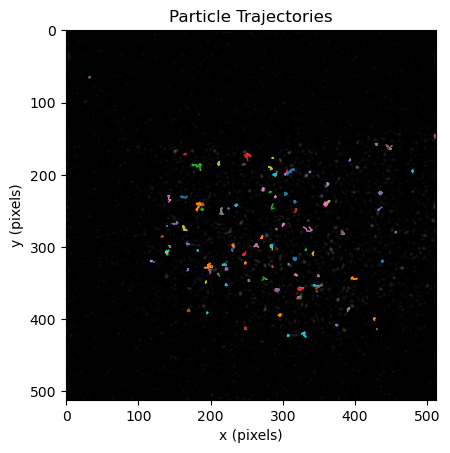

In [10]:
def plot_trajectories(trajs, background_image=None):
    """
    Plot all trajectories stored in 'trajs'.

    trajs: list of trajectories, where each trajectory is a list of (x,y) coordinates.
    background_image: optional 2D or 3D image to show underneath trajectory lines.
    figsize: figure size.
    """
    plt.figure()

    # Optional background image
    if background_image is not None:
        if background_image.ndim == 2:
            plt.imshow(background_image, cmap='gray')
        else:
            plt.imshow(background_image)
    
    # Plot each trajectory
    for traj in trajs:
        traj = np.array(traj)  # shape (T, 2)

        xs = traj[:,0]
        ys = traj[:,1]

        # Line
        plt.plot(xs, ys, linewidth=1)

        # Start & end markers
        #plt.scatter(xs[0], ys[0], marker='o', s=0.5)   # start
        #plt.scatter(xs[-1], ys[-1], marker='x', s=0.5) # end

    plt.title("Particle Trajectories")
    plt.xlabel("x (pixels)")
    plt.ylabel("y (pixels)")
    #plt.gca().invert_yaxis()  # because image coordinates have y downward
    plt.grid(False)
    plt.show()
    
plot_trajectories(trajs, background_image=imgWL[0])

# Define functions for Trajectory viewing and Mean Squared Displacement computation 

In [24]:
def px2pos(px_arr):
    return px_arr*ExpInfo.scale

def MSD_curve_3_noStop(fp, show=True):
    ''' 
    - return t_arr (simply lag_arr in units of t), msd_curve
    ''' 
    track_px = fp
    track_pos = px2pos(track_px)
    N_steps = fp.shape[0]

    msd_curve = np.zeros(len(track_px)-1)
    lag_arr = np.arange(1, len(track_px))

    for m in lag_arr:
        msd_curve[m-1] = MSD_lag_v2(track_pos, m)

    t_arr = lag_arr*ExpInfo.dt*10**-3

    if show:
        fig, ax = plt.subplots()
        ax.plot(t_arr, msd_curve, c = 'black', lw=1)
        ax.set(xlabel = f'Lag time [s]', ylabel = f'MSD [${ExpInfo.unit}^2$]')

    return t_arr, msd_curve

    
def track_dist(track):
    N = track.shape[0]
    displ = track[1:N] - track[0:N-1]
    SD = displ.T[0]**2 + displ.T[1]**2
    return np.sqrt(SD)

def get_track_lims(track, offset=5):
    ''' 
    - track: (N_ptcl, 2)-array
    '''

    # offset = 5
    x,y = track.T

    # xmin = x.min()-5
    # xma

    t_lims = np.zeros((2,2), dtype=int) # why not
    for i in range(2):
        t_lims[i, 0] = track.T[i].min() - offset
        t_lims[i, 1] = track.T[i].max() + offset

    return t_lims


def show_cropped_im(im_arr, col_xs, row_ys, **kwargs):
    ''' 
    * Handles incorrect indices. col_xs, row_ys can be out of bounds or not ints, will handle
    '''
    fig, ax = plt.subplots()

    n = im_arr.shape[0]
    for arr in [col_xs, row_ys]:
        for i in [0,1]:
            arr[i] = int(arr[i])
        arr[0] = max(arr[0], 0)
        arr[1] = min(n, arr[1])

    cropped_im = im_arr[row_ys[0]:row_ys[1], col_xs[0]:col_xs[1]]
    im = ax.imshow(cropped_im, extent=(col_xs[0], col_xs[1], row_ys[1], row_ys[0]), **kwargs)
    cbar = fig.colorbar(im, ax=ax)
    return fig, ax, cbar



def add_track_noStop(ax, fp, **line_kwarg):
    track = fp
    line = Line2D(track.T[0], track.T[1], **default_kwargs(line_kwarg, c = 'white', lw = 1))
    ax.add_line(line)
    
    
    
def linear(x, a, b):
    return a*x + b

def linearZero(x, a):
    return a*x 

def delay_track(track, m):
    '''
    Select an "m-delayed" subtrack of the input track, which contains every m-th position in track \n
    * track: expect a (N, 2)-array \n
    * m: 1 <= m <= N-1
    '''
    N = track.shape[0]
    if m not in range(1, N):
        raise ValueError('require 1 <= m <= N-1')  
    mask_arr = (np.arange(0, N) % m) == 0
    return track[mask_arr]


def MSD_lag_v2(track, m):
    ''' 
    * track: (N, 2)-array of x,y-positions
    * m should range from from 0 to N-1
    '''
    N = track.shape[0]
    if m not in range(1, N):
        raise ValueError('require 1 <= m <= N-1')  
    delayed_track = delay_track(track, m)
    M = delayed_track.shape[0] 
    displ = delayed_track[1:M] - delayed_track[0:M-1]
    SD = displ.T[0]**2 + displ.T[1]**2
    return np.mean(SD)

def MSD_curve_ij_noStop(fp, tj, i=1, j=10, show=True):

    track_px = fp
    track_pos = px2pos(track_px)

    lag_arr = np.arange(i, j+1)
    n_pts = j+1-i
    msd_curve = np.zeros(n_pts)

    for idx in range(n_pts):
        m = lag_arr[idx]
        msd_curve[idx] = MSD_lag_v2(track_pos, m)

    t_arr = lag_arr*ExpInfo.dt*10**-3

    ## Fit

    popt, pcov = opt.curve_fit(linearZero, t_arr, msd_curve)
    R2 = r2_score(msd_curve, linearZero(t_arr, *popt)) #ydata,ypredicted; R2 calculation may not be correct 
    
    D = popt[0]/4 # for 2D diffusion 
    #D = popt[0]/6 # for 3D diffusion 

    if show==True:
        #fig, ax = plt.subplots()
        ax.scatter(t_arr, msd_curve,marker='.')
        ax.plot(t_arr, linearZero(t_arr, *popt), ls='--')
        #ax.set_xticks(t_arr)
        #ax.set_xticklabels(1000*t_arr)
        ax.set(xlabel = f'Lag time [{ExpInfo.dt_unit}]', ylabel = f'MSD [${ExpInfo.unit}^2$]')
        
        #if tj>=0:
            #ax.set_title(f'Traj{tj}: D ({i} to {j}) = {round(D, 4)} ${ExpInfo.unit}^2/s$')
        #else:
            #ax.set_title(f'D ({i} to {j}) = {round(D, 4)} ${ExpInfo.unit}^2/s$')
        #display(Math(f'D ({i} to {j}) = {round(D, 4)} {ExpInfo.unit}^2/s'))

    
    return D, R2#, t_arr, msd_curve, popt 

# View example trajectory 

(np.float64(0.4464919334531138), 0.8419074936504507)

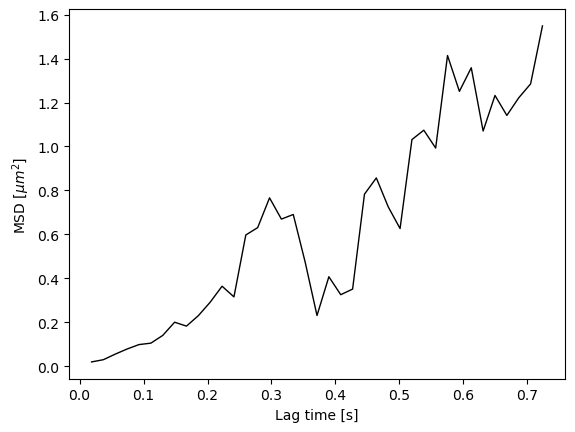

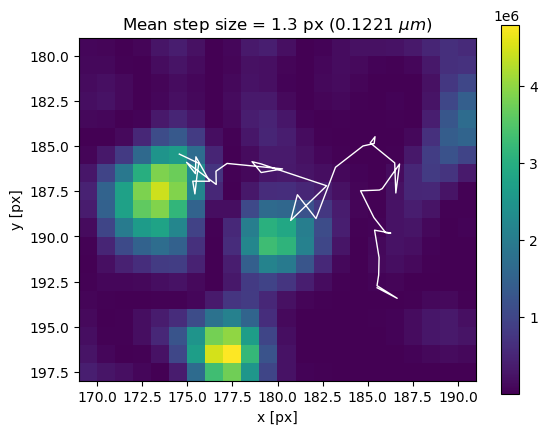

In [25]:
trajToView = 2

track = trajs[trajToView] # track should be an Ntrack x 2 array of (x,y) coordinates, where Ntrack is the # of steps in the current trajectory 
track = np.array([track])[0] # convert track from list to array, in the right format 

t, msd = MSD_curve_3_noStop(track)
lims = get_track_lims(track, offset=5)

fig, ax, _ = show_cropped_im(imgWL[0], *lims) #, cmap='gray')
add_track_noStop(ax, track) #, c='black') #, lw=1)

avg_step = track_dist(track).mean()

ax.set(
    title = f'Mean step size = {round(avg_step,2)} px ({round(avg_step*ExpInfo.scale,4)} ${ExpInfo.unit}$)',
    xlabel = 'x [px]', ylabel = 'y [px]'
)

MSD_curve_ij_noStop(track, tj=-1, i=1, j=len(track)-1, show=False) # i,j are the start and end points of the linear fit for D 


# Now loop thru all trajectories 

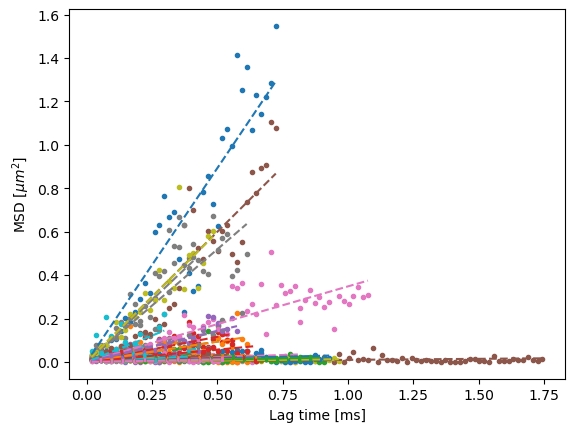

In [26]:
# Only take trajectories with greater than a threhsold number of points 
trajs_long = [elem for elem in trajs if len(elem) > 15]
trajs_badFits = [] # trajectories to omit 
trajs_good = [val for i, val in enumerate(trajs_long) if i not in trajs_badFits]


fig, ax = plt.subplots()
#plt.ylim(0,0.2)
#plt.xlim(0,0.1)

D = np.zeros([len(trajs_good),1])
R2 = np.zeros([len(trajs_good),1])
for tj in range(len(trajs_good)):
    track = trajs_good[tj] # track should be an Ntrack x 2 array of (x,y) coordinates, where Ntrack is the # of steps in the current trajectory 
    track = np.array([track])[0] # convert track from list to array, in the right format 

    t, msd = MSD_curve_3_noStop(track, show=False)
        
    #lims = get_track_lims(track, offset=5)
    #fig, ax, _ = show_cropped_im(imgWL[0], *lims) #, cmap='gray')
    #add_track_noStop(ax, track) #, c='black') #, lw=1)
    
    avg_step = track_dist(track).mean()
    
    #ax.set(
    #    title = f'Mean step size = {round(avg_step,2)} px ({round(avg_step*ExpInfo.scale,4)} ${ExpInfo.unit}$)',
    #    xlabel = 'x [px]', ylabel = 'y [px]'
    #)
    
    D[tj],R2[tj] = MSD_curve_ij_noStop(track, tj, i=1, j=len(track)-1, show=True) # i,j are the start and end points of the linear fit for D 
